<a href="https://colab.research.google.com/github/thuynguyenhuit/hocsau/blob/main/M%C3%B4_h%C3%ACnh_MLP_Dry_Bean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import pandas as pd
pd_train = pd.read_csv("https://raw.githubusercontent.com/thuynguyenhuit/hocsau/refs/heads/main/Dry_Bean_Dataset.csv")

In [86]:
# =========================================
# IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim

In [87]:
pd_train.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [88]:
# =========================================
# KIỂM TRA DỮ LIỆU
# =========================================
print(pd_train.info())

print(pd_train["Class"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [89]:
# =========================================
# Mã hóa nhãn (Label Encoding) cho biến mục tiêu
# =========================================

encoder = LabelEncoder()

pd_train["Class"] = encoder.fit_transform(pd_train["Class"])

print(pd_train.head())

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358      0.007332  

In [90]:
# =========================================
# TÁCH X VÀ y
# =========================================

X = pd_train.drop("Class", axis=1)

y = pd_train["Class"]

In [91]:
# =========================================
# CHIA TRAIN / VAL / TEST
# Train: 70%, Val: 15%, Test: 15%
# =========================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

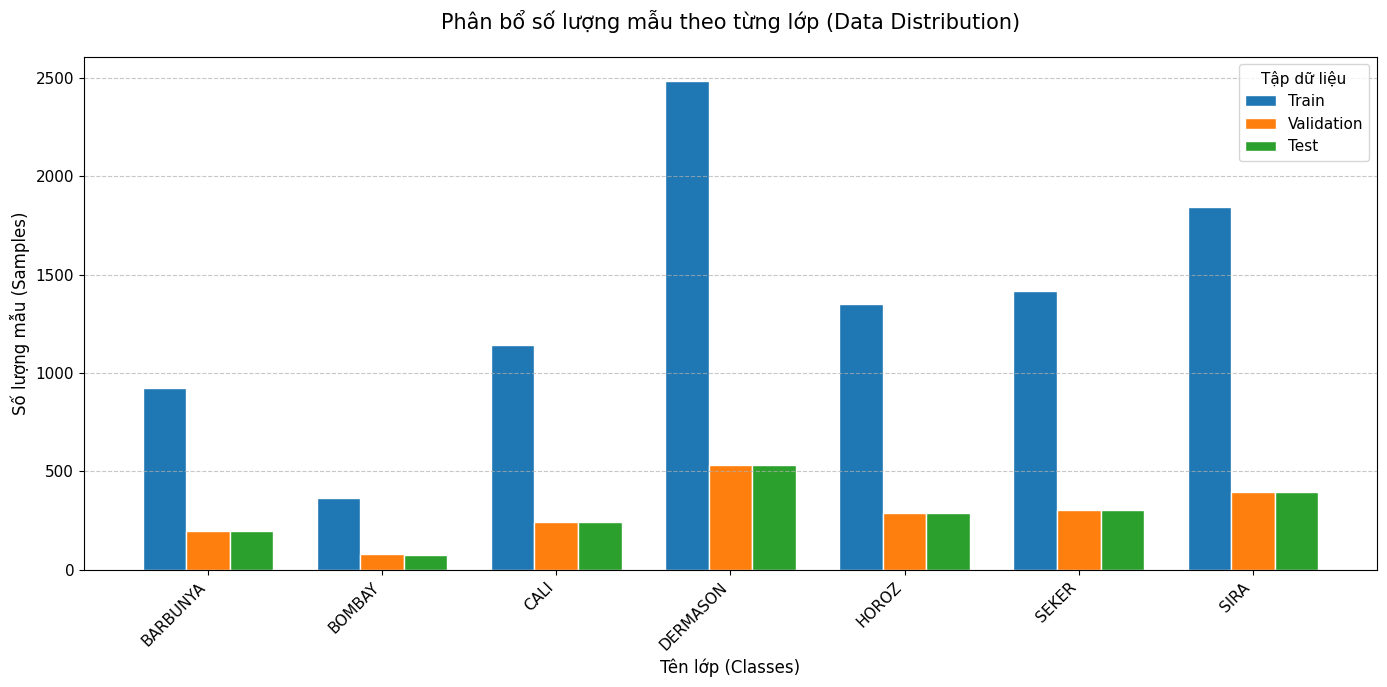

In [92]:
# Vẽ biểu đồ số lượng mẫu của từng tập dữ liệu train/val/test
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# 1. ĐẾM SỐ LƯỢNG MẪU (Trực tiếp từ Series)
# =========================================
# Giả định y_train, y_val, y_test là các Pandas Series
# Nếu chúng là Tensor, hãy dùng .to_numpy() trước khi đếm

train_counts = y_train.value_counts().sort_index()
val_counts = y_val.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

# =========================================
# 2. CLASS NAMES
# =========================================
# Lấy tên các lớp từ LabelEncoder bạn đã dùng trước đó
class_names = encoder.classes_

# =========================================
# 3. VẼ BIỂU ĐỒ CỘT (GROUPED BAR CHART)
# =========================================
x = range(len(class_names))
width = 0.25  # Độ rộng của mỗi cột

plt.figure(figsize=(14, 7))

# Vẽ từng nhóm cột cho Train, Validation, Test
plt.bar(
    [i - width for i in x],
    train_counts,
    width=width,
    label='Train',
    color='#1f77b4',
    edgecolor='white'
)

plt.bar(
    x,
    val_counts,
    width=width,
    label='Validation',
    color='#ff7f0e',
    edgecolor='white'
)

plt.bar(
    [i + width for i in x],
    test_counts,
    width=width,
    label='Test',
    color='#2ca02c',
    edgecolor='white'
)

# =========================================
# 4. TRÌNH BÀY (LABELS & STYLE)
# =========================================
plt.title("Phân bổ số lượng mẫu theo từng lớp (Data Distribution)", fontsize=15, pad=20)
plt.xlabel("Tên lớp (Classes)", fontsize=12)
plt.ylabel("Số lượng mẫu (Samples)", fontsize=12)

# Thiết lập nhãn trục X
plt.xticks(x, class_names, rotation=45, ha='right')

# Thêm chú thích
plt.legend(title="Tập dữ liệu")

# Thêm lưới ngang để dễ quan sát số lượng
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tự động căn chỉnh để không bị mất nhãn phía dưới
plt.tight_layout()

plt.show()

In [94]:
# =========================================
# SCALE FEATURES
# =========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [95]:
# Thêm phiên bản SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [97]:
# chuẩn hóa kiểu dữ liệu và chuyển đổi các tập dữ liệu từ các thư viện Python thông thường (như Pandas hay NumPy) sang định dạng PyTorch Tensor.
# Đây là bước tiền xử lý bắt buộc để có thể nạp dữ liệu vào huấn luyện các mô hình Deep Learning trong PyTorch.
import numpy as np
import pandas as pd
import torch

X_train_tensor = torch.tensor(np.array(X_train), dtype=torch.float32)
X_val_tensor   = torch.tensor(np.array(X_val), dtype=torch.float32)
X_test_tensor  = torch.tensor(np.array(X_test), dtype=torch.float32)

y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)
y_val_tensor   = torch.tensor(np.array(y_val), dtype=torch.long)
y_test_tensor  = torch.tensor(np.array(y_test), dtype=torch.long)

# ==========================================
# 2. Chuyển đổi tập dữ liệu sau khi SMOTE
# ==========================================
X_train_smote_tensor = torch.tensor(np.array(X_train_smote), dtype=torch.float32)
y_train_smote_tensor = torch.tensor(np.array(y_train_smote), dtype=torch.long)

# ==========================================
# 3. Kiểm tra lại kích thước
# ==========================================
print("--- Kích thước các Tensor tập gốc ---")
print(f"X_train: {X_train_tensor.shape}, y_train: {y_train_tensor.shape}")
print(f"X_val:   {X_val_tensor.shape}, y_val:   {y_val_tensor.shape}")
print(f"X_test:  {X_test_tensor.shape}, y_test:  {y_test_tensor.shape}")

print("\n--- Kích thước các Tensor sau SMOTE ---")
print(f"X_train_smote: {X_train_smote_tensor.shape}, y_train_smote: {y_train_smote_tensor.shape}")

--- Kích thước các Tensor tập gốc ---
X_train: torch.Size([9527, 16]), y_train: torch.Size([9527])
X_val:   torch.Size([2042, 16]), y_val:   torch.Size([2042])
X_test:  torch.Size([2042, 16]), y_test:  torch.Size([2042])

--- Kích thước các Tensor sau SMOTE ---
X_train_smote: torch.Size([17374, 16]), y_train_smote: torch.Size([17374])


In [98]:
# =========================================
# INPUT SIZE
# =========================================

input_size = X_train.shape[1]

print(input_size)

16


MÔ HÌNH KHÔNG DROPOUT

In [99]:
# =========================================
# MODEL KHÔNG DROPOUT
# =========================================

class MLP_NoDropout(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 7)
        )

    def forward(self, x):
        return self.network(x)

MÔ HÌNH CÓ DROPOUT

In [100]:
# =========================================
# MODEL CÓ DROPOUT
# =========================================

class MLP_Dropout(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 7)
        )

    def forward(self, x):
        return self.network(x)

TRAIN MODEL

In [101]:
# =========================================
# 12. HÀM TRAIN
# =========================================

def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=700
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # =========================
        # TRAIN
        # =========================

        model.train() #Bật chế độ "đang học"

        outputs = model(X_train) #Dự đoán thử trên tập dữ liệu học

        loss = criterion(outputs, y_train)

        optimizer.zero_grad() #Xóa các tính toán cũ để chuẩn bị cho vòng lặp mới (tránh cộng dồn sai số cũ).

        loss.backward() #Tính toán xem lỗi nằm ở đâu (Lan truyền ngược)

        optimizer.step() #Cập nhật trọng số của mô hình để lần sau không mắc lại lỗi cũ

        train_losses.append(loss.item())

        _, predicted = torch.max(outputs, 1)

        train_acc = (
            predicted == y_train
        ).float().mean()

        train_accuracies.append(
            train_acc.item()
        )

        # =========================
        # VALIDATION
        # =========================

        model.eval() # Lúc này Dropout sẽ bị tắt đi để dự đoán ổn định nhất.

        with torch.no_grad(): #Tạm dừng việc tính toán đạo hàm để tiết kiệm bộ nhớ và chạy nhanh hơn
                              #(vì lúc này chỉ kiểm tra chứ không cập nhật trọng số).

            val_outputs = model(X_val)

            val_loss = criterion(
                val_outputs,
                y_val
            )

            val_losses.append(
                val_loss.item()
            )
        #tìm giá trị lớn nhất theo hàng (chiều thứ 1), Nhận về vị trí (index) của giá trị lớn nhất đó
            _, val_predicted = torch.max(
                val_outputs,
                1
            )

            val_acc = (
                val_predicted == y_val #So sánh từng dự đoán với nhãn thực tế
            ).float().mean()

            val_accuracies.append(
                val_acc.item()
            )

        if (epoch + 1) % 50 == 0:

            print(
                f"Epoch {epoch+1}/{epochs}"
                f" | Train Loss: {loss.item():.4f}"
                f" | Val Loss: {val_loss.item():.4f}"
                f" | Train Acc: {train_acc.item():.4f}"
                f" | Val Acc: {val_acc.item():.4f}"
            )

    return (
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies
    )

TRAIN MODEL KHÔNG DROPOUT, KHÔNG SMOTE

In [102]:
# =========================================
# KỊCH BẢN 1: TRAIN NO DROPOUT, NO SMOTE
# =========================================

model_no_dropout = MLP_NoDropout(input_size)

(
    train_loss_no,
    val_loss_no,
    train_acc_no,
    val_acc_no

) = train_model(
    model_no_dropout,
    X_train_tensor,
    y_train_tensor,
    X_val_tensor,
    y_val_tensor
)

Epoch 50/700 | Train Loss: 0.7766 | Val Loss: 0.7413 | Train Acc: 0.8025 | Val Acc: 0.8085
Epoch 100/700 | Train Loss: 0.2468 | Val Loss: 0.2436 | Train Acc: 0.9143 | Val Acc: 0.9128
Epoch 150/700 | Train Loss: 0.2043 | Val Loss: 0.2123 | Train Acc: 0.9237 | Val Acc: 0.9187
Epoch 200/700 | Train Loss: 0.1911 | Val Loss: 0.2043 | Train Acc: 0.9291 | Val Acc: 0.9231
Epoch 250/700 | Train Loss: 0.1834 | Val Loss: 0.2006 | Train Acc: 0.9325 | Val Acc: 0.9270
Epoch 300/700 | Train Loss: 0.1779 | Val Loss: 0.1983 | Train Acc: 0.9347 | Val Acc: 0.9265
Epoch 350/700 | Train Loss: 0.1734 | Val Loss: 0.1968 | Train Acc: 0.9356 | Val Acc: 0.9285
Epoch 400/700 | Train Loss: 0.1695 | Val Loss: 0.1956 | Train Acc: 0.9371 | Val Acc: 0.9310
Epoch 450/700 | Train Loss: 0.1659 | Val Loss: 0.1946 | Train Acc: 0.9389 | Val Acc: 0.9280
Epoch 500/700 | Train Loss: 0.1624 | Val Loss: 0.1937 | Train Acc: 0.9408 | Val Acc: 0.9270
Epoch 550/700 | Train Loss: 0.1588 | Val Loss: 0.1927 | Train Acc: 0.9421 | Val A

TRAIN MODEL CÓ DROPOUT, KHÔNG SMOTE

In [103]:
# =========================================
# KỊCH BẢN 2: TRAIN DROPOUT, NO SMOTE
# =========================================

model_dropout = MLP_Dropout(input_size)

(
    train_loss_drop,
    val_loss_drop,
    train_acc_drop,
    val_acc_drop
) = train_model(
    model_dropout,
    X_train_tensor,
    y_train_tensor,
    X_val_tensor,
    y_val_tensor
)

Epoch 50/700 | Train Loss: 0.6689 | Val Loss: 0.5726 | Train Acc: 0.7566 | Val Acc: 0.7968
Epoch 100/700 | Train Loss: 0.3782 | Val Loss: 0.3003 | Train Acc: 0.8693 | Val Acc: 0.8952
Epoch 150/700 | Train Loss: 0.2806 | Val Loss: 0.2268 | Train Acc: 0.9060 | Val Acc: 0.9212
Epoch 200/700 | Train Loss: 0.2514 | Val Loss: 0.2119 | Train Acc: 0.9132 | Val Acc: 0.9231
Epoch 250/700 | Train Loss: 0.2371 | Val Loss: 0.2068 | Train Acc: 0.9183 | Val Acc: 0.9251
Epoch 300/700 | Train Loss: 0.2245 | Val Loss: 0.2047 | Train Acc: 0.9220 | Val Acc: 0.9265
Epoch 350/700 | Train Loss: 0.2238 | Val Loss: 0.2032 | Train Acc: 0.9267 | Val Acc: 0.9265
Epoch 400/700 | Train Loss: 0.2213 | Val Loss: 0.2026 | Train Acc: 0.9220 | Val Acc: 0.9280
Epoch 450/700 | Train Loss: 0.2151 | Val Loss: 0.2012 | Train Acc: 0.9265 | Val Acc: 0.9275
Epoch 500/700 | Train Loss: 0.2098 | Val Loss: 0.2000 | Train Acc: 0.9273 | Val Acc: 0.9290
Epoch 550/700 | Train Loss: 0.2038 | Val Loss: 0.1995 | Train Acc: 0.9296 | Val A

TRAIN MODEL KHÔNG DROPOUT, KHÔNG SMOTE

In [104]:
# =========================================
# KỊCH BẢN 3: TRAIN NO DROPOUT, SMOTE
# =========================================

model_no_dropout_smote = MLP_NoDropout(input_size)

(
    train_loss_no_smote,
    val_loss_no_smote,
    train_acc_no_smote,
    val_acc_no_smote
) = train_model(
    model_no_dropout_smote,
    X_train_smote_tensor,
    y_train_smote_tensor,
    X_val_tensor,
    y_val_tensor
)

Epoch 50/700 | Train Loss: 0.5489 | Val Loss: 0.6048 | Train Acc: 0.8325 | Val Acc: 0.7914
Epoch 100/700 | Train Loss: 0.2021 | Val Loss: 0.2519 | Train Acc: 0.9346 | Val Acc: 0.9089
Epoch 150/700 | Train Loss: 0.1610 | Val Loss: 0.2107 | Train Acc: 0.9413 | Val Acc: 0.9207
Epoch 200/700 | Train Loss: 0.1499 | Val Loss: 0.2032 | Train Acc: 0.9453 | Val Acc: 0.9256
Epoch 250/700 | Train Loss: 0.1435 | Val Loss: 0.2001 | Train Acc: 0.9477 | Val Acc: 0.9275
Epoch 300/700 | Train Loss: 0.1390 | Val Loss: 0.1993 | Train Acc: 0.9497 | Val Acc: 0.9300
Epoch 350/700 | Train Loss: 0.1353 | Val Loss: 0.1988 | Train Acc: 0.9513 | Val Acc: 0.9280
Epoch 400/700 | Train Loss: 0.1319 | Val Loss: 0.1983 | Train Acc: 0.9524 | Val Acc: 0.9280
Epoch 450/700 | Train Loss: 0.1285 | Val Loss: 0.1976 | Train Acc: 0.9530 | Val Acc: 0.9280
Epoch 500/700 | Train Loss: 0.1254 | Val Loss: 0.1973 | Train Acc: 0.9548 | Val Acc: 0.9280
Epoch 550/700 | Train Loss: 0.1226 | Val Loss: 0.1973 | Train Acc: 0.9570 | Val A

TRAIN MODEL CÓ DROPOUT, CÓ SMOTE

In [105]:
# =========================================
# KỊCH BẢN 4: TRAIN DROPOUT, SMOTE
# =========================================

model_dropout_smote = MLP_Dropout(input_size)

(
    train_loss_smote,
    val_loss_smote,
    train_acc_smote,
    val_acc_smote
) = train_model(
    model_dropout_smote,
    X_train_smote_tensor,
    y_train_smote_tensor,
    X_val_tensor,
    y_val_tensor
)

Epoch 50/700 | Train Loss: 0.7309 | Val Loss: 0.7223 | Train Acc: 0.7381 | Val Acc: 0.7395
Epoch 100/700 | Train Loss: 0.3215 | Val Loss: 0.3044 | Train Acc: 0.8863 | Val Acc: 0.8937
Epoch 150/700 | Train Loss: 0.2372 | Val Loss: 0.2269 | Train Acc: 0.9200 | Val Acc: 0.9202
Epoch 200/700 | Train Loss: 0.2080 | Val Loss: 0.2128 | Train Acc: 0.9291 | Val Acc: 0.9231
Epoch 250/700 | Train Loss: 0.1960 | Val Loss: 0.2095 | Train Acc: 0.9325 | Val Acc: 0.9251
Epoch 300/700 | Train Loss: 0.1868 | Val Loss: 0.2082 | Train Acc: 0.9363 | Val Acc: 0.9265
Epoch 350/700 | Train Loss: 0.1785 | Val Loss: 0.2077 | Train Acc: 0.9381 | Val Acc: 0.9270
Epoch 400/700 | Train Loss: 0.1768 | Val Loss: 0.2080 | Train Acc: 0.9402 | Val Acc: 0.9280
Epoch 450/700 | Train Loss: 0.1681 | Val Loss: 0.2068 | Train Acc: 0.9439 | Val Acc: 0.9275
Epoch 500/700 | Train Loss: 0.1648 | Val Loss: 0.2073 | Train Acc: 0.9434 | Val Acc: 0.9270
Epoch 550/700 | Train Loss: 0.1654 | Val Loss: 0.2065 | Train Acc: 0.9429 | Val A

VẼ LOSS CURVE

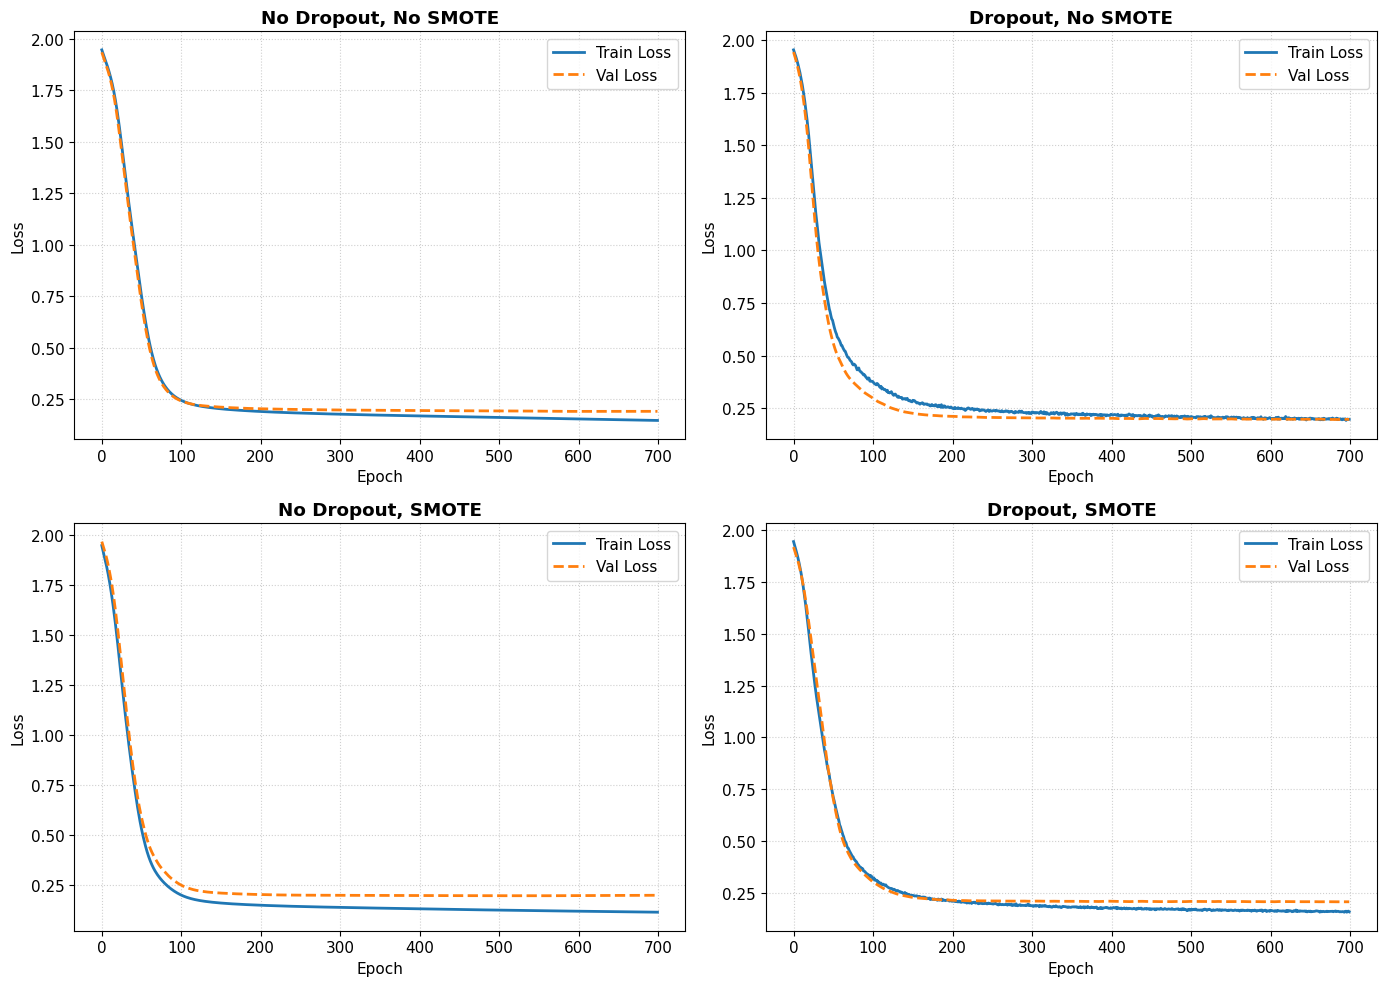

In [106]:
import matplotlib.pyplot as plt

# Cấu hình kích thước và kiểu dáng tổng thể cho biểu đồ
plt.figure(figsize=(14, 10))
plt.rcParams["font.size"] = 11

# ========================================================
# Kịch bản 1: No Dropout, No SMOTE
# ========================================================
plt.subplot(2, 2, 1)
plt.plot(train_loss_no, label="Train Loss", color="#1f77b4", linewidth=2)
plt.plot(
    val_loss_no,
    label="Val Loss",
    color="#ff7f0e",
    linestyle="--",
    linewidth=2,
)
plt.title("No Dropout, No SMOTE", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# ========================================================
# Kịch bản 2: Dropout, No SMOTE
# ========================================================
plt.subplot(2, 2, 2)
plt.plot(train_loss_drop, label="Train Loss", color="#1f77b4", linewidth=2)
plt.plot(
    val_loss_drop,
    label="Val Loss",
    color="#ff7f0e",
    linestyle="--",
    linewidth=2,
)
plt.title("Dropout, No SMOTE", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# ========================================================
# Kịch bản 3: No Dropout, SMOTE
# ========================================================
plt.subplot(2, 2, 3)
plt.plot(
    train_loss_no_smote, label="Train Loss", color="#1f77b4", linewidth=2
)
plt.plot(
    val_loss_no_smote,
    label="Val Loss",
    color="#ff7f0e",
    linestyle="--",
    linewidth=2,
)
plt.title("No Dropout, SMOTE", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# ========================================================
# Kịch bản 4: Dropout, SMOTE
# ========================================================
plt.subplot(2, 2, 4)
plt.plot(train_loss_smote, label="Train Loss", color="#1f77b4", linewidth=2)
plt.plot(
    val_loss_smote,
    label="Val Loss",
    color="#ff7f0e",
    linestyle="--",
    linewidth=2,
)
plt.title("Dropout, SMOTE", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# Tự động căn chỉnh khoảng cách giữa các biểu đồ con để không bị đè chữ
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

VẼ ACCURACY CURVE

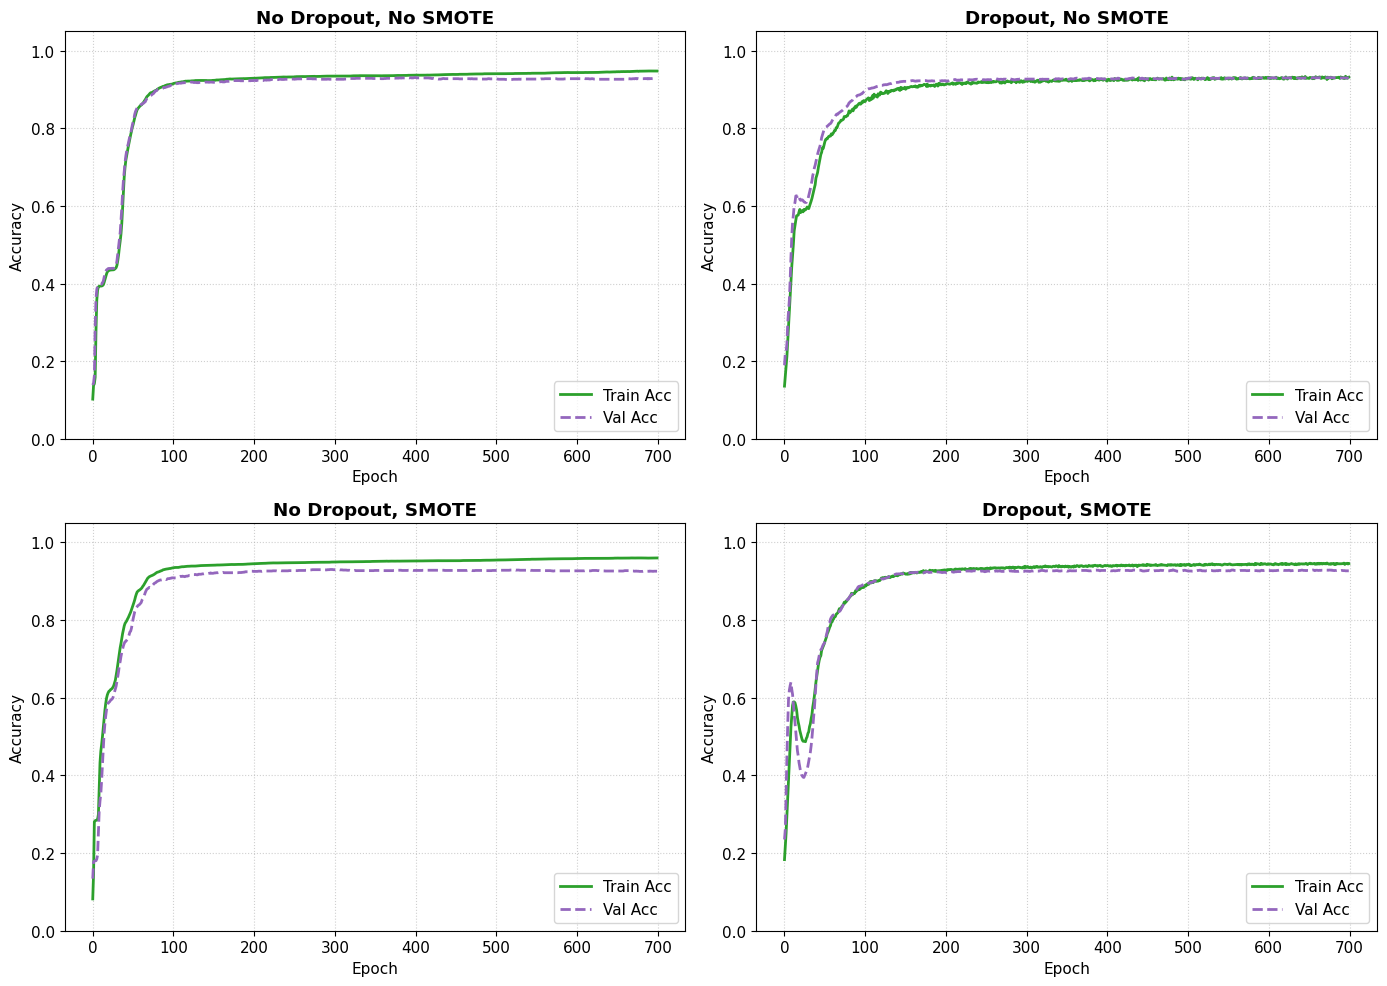

In [107]:
import matplotlib.pyplot as plt

# Khởi tạo kích thước tổng thể cho khung hình (2 hàng x 2 cột)
plt.figure(figsize=(14, 10))
plt.rcParams["font.size"] = 11

# Định nghĩa màu sắc cố định để đồ thị nhìn chuyên nghiệp
train_color = "#2ca02c"  # Màu xanh lá đại diện cho Train Accuracy
val_color = "#9467bd"  # Màu tím đại diện cho Val Accuracy

# ========================================================
# Kịch bản 1: No Dropout, No SMOTE (Đoạn 13)
# ========================================================
plt.subplot(2, 2, 1)
plt.plot(train_acc_no, label="Train Acc", color=train_color, linewidth=2)
plt.plot(
    val_acc_no, label="Val Acc", color=val_color, linestyle="--", linewidth=2
)
plt.title("No Dropout, No SMOTE", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim([0, 1.05])  # Thang đo chuẩn từ 0 đến 100%
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower right")

# ========================================================
# Kịch bản 2: Dropout, No SMOTE (Đoạn 14 cũ)
# ========================================================
plt.subplot(2, 2, 2)
plt.plot(train_acc_drop, label="Train Acc", color=train_color, linewidth=2)
plt.plot(
    val_acc_drop, label="Val Acc", color=val_color, linestyle="--", linewidth=2
)
plt.title("Dropout, No SMOTE", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim([0, 1.05])
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower right")

# ========================================================
# Kịch bản 3: No Dropout, SMOTE (Đoạn 15)
# ========================================================
plt.subplot(2, 2, 3)
plt.plot(
    train_acc_no_smote, label="Train Acc", color=train_color, linewidth=2
)
plt.plot(
    val_acc_no_smote,
    label="Val Acc",
    color=val_color,
    linestyle="--",
    linewidth=2,
)
plt.title("No Dropout, SMOTE", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim([0, 1.05])
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower right")

# ========================================================
# Kịch bản 4: Dropout, SMOTE (Đoạn 14 mới)
# ========================================================
plt.subplot(2, 2, 4)
plt.plot(train_acc_smote, label="Train Acc", color=train_color, linewidth=2)
plt.plot(
    val_acc_smote, label="Val Acc", color=val_color, linestyle="--", linewidth=2
)
plt.title("Dropout, SMOTE", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim([0, 1.05])
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower right")

# Căn chỉnh tự động khoảng cách giữa các khung hình để chữ không bị đè lên nhau
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

TÍNH TOÁN CÁC CHỈ SỐ PRECISION, RECALL, F1-SCORES

In [108]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score, precision_score, recall_score

# Tạo một danh sách cấu hình để duyệt qua 4 kịch bản cho nhanh
scenarios = [
    {
        "name": "No Dropout, No SMOTE",
        "model": model_no_dropout,
        "x_test": X_test_tensor,
        "y_test": y_test_tensor,
    },
    {
        "name": "Dropout, No SMOTE",
        "model": model_dropout,
        "x_test": X_test_tensor,
        "y_test": y_test_tensor,
    },
    {
        "name": "No Dropout, SMOTE",
        "model": model_no_dropout_smote,
        "x_test": X_test_tensor,
        "y_test": y_test_tensor,
    },
    {
        "name": "Dropout, SMOTE",
        "model": model_dropout_smote,
        "x_test": X_test_tensor,
        "y_test": y_test_tensor,
    },
]

# Danh sách chứa kết quả tính toán
results_list = []

# Duyệt qua từng kịch bản để đánh giá trên tập Test
for sc in scenarios:
    model = sc["model"]
    X_t = sc["x_test"]
    y_t = sc["y_test"]

    # Đưa mô hình về chế độ đánh giá (Evaluation mode) - Bắt buộc để tắt Dropout khi test
    model.eval()

    with torch.no_grad():
        # 1. Dự đoán logits từ mô hình
        outputs = model(X_t)
        # 2. Lấy chỉ số có xác suất cao nhất làm nhãn dự đoán (0, 1, 2...)
        _, preds = torch.max(outputs, 1)

    # Chuyển Tensor sang NumPy array để dùng với scikit-learn
    y_true = y_t.cpu().numpy()
    y_pred = preds.cpu().numpy()

    # Tính toán các chỉ số (Sử dụng average='macro' hoặc 'weighted' tùy thuộc vào bài toán đa lớp)
    # Nếu là bài toán phân loại nhị phân (2 lớp), bạn có thể đổi thành average='binary'
    avg_method = "macro"

    precision = precision_score(y_true, y_pred, average=avg_method)
    recall = recall_score(y_true, y_pred, average=avg_method)
    f1 = f1_score(y_true, y_pred, average=avg_method)

    # Lưu vào danh sách kết quả
    results_list.append(
        {
            "Kịch bản huấn luyện": sc["name"],
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1-Score": round(f1, 4),
        }
    )

# ========================================================
# HIỂN THỊ KẾT QUẢ DẠNG BẢNG
# ========================================================
df_results = pd.DataFrame(results_list)

print("============== BẢNG SO SÁNH HIỆU NĂNG TRÊN TẬP TEST ==============")
display(df_results)  # Sử dụng display() để giao diện Jupyter Notebook tự vẽ bảng đẹp

============== BẢNG SO SÁNH HIỆU NĂNG TRÊN TẬP TEST ==============


,Kịch bản huấn luyện,Precision,Recall,F1-Score
0,"No Dropout, No SMOTE",0.9371,0.9358,0.9364
1,"Dropout, No SMOTE",0.9373,0.9358,0.9365
2,"No Dropout, SMOTE",0.9345,0.9359,0.9349
3,"Dropout, SMOTE",0.9335,0.9343,0.9337


ĐƯỜNG CONG Precision-Recall

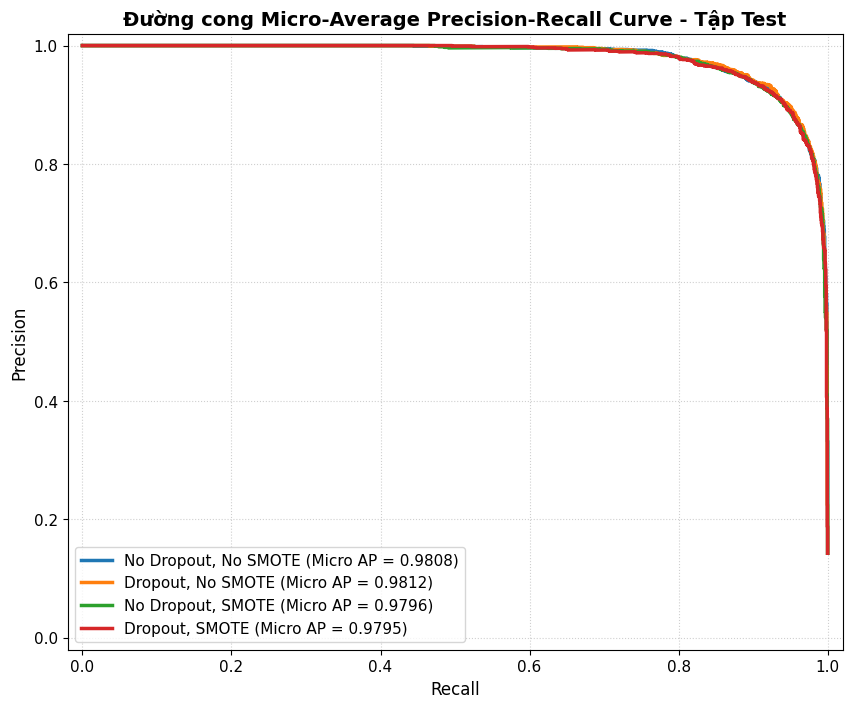

In [109]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Giả định số lớp (ví dụ: 3 lớp, 5 lớp...). Hãy đổi lại cho đúng với số lớp của bạn:
num_classes = len(torch.unique(y_test_tensor))
y_true = y_test_tensor.cpu().numpy()

# Chuyển nhãn sang dạng One-hot vector
y_true_binarized = label_binarize(y_true, classes=np.arange(num_classes))

scenarios = [
    {"name": "No Dropout, No SMOTE", "model": model_no_dropout},
    {"name": "Dropout, No SMOTE", "model": model_dropout},
    {"name": "No Dropout, SMOTE", "model": model_no_dropout_smote},
    {"name": "Dropout, SMOTE", "model": model_dropout_smote},
]

plt.figure(figsize=(10, 8))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, sc in enumerate(scenarios):
    model = sc["model"]
    model.eval()

    with torch.no_grad():
        outputs = model(X_test_tensor)
        probabilities = F.softmax(outputs, dim=1).cpu().numpy()

    # Tính toán Micro-average PR
    precision, recall, _ = precision_recall_curve(
        y_true_binarized.ravel(), probabilities.ravel()
    )
    ap_score = average_precision_score(
        y_true_binarized, probabilities, average="micro"
    )

    plt.plot(
        recall,
        precision,
        color=colors[i],
        linewidth=2.5,
        label=f"{sc['name']} (Micro AP = {ap_score:.4f})",
    )

plt.title("Đường cong Micro-Average Precision-Recall Curve - Tập Test", fontsize=14, fontweight="bold")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower left", fontsize=11)
plt.show()

MA TRẬN NHẦM LẪN

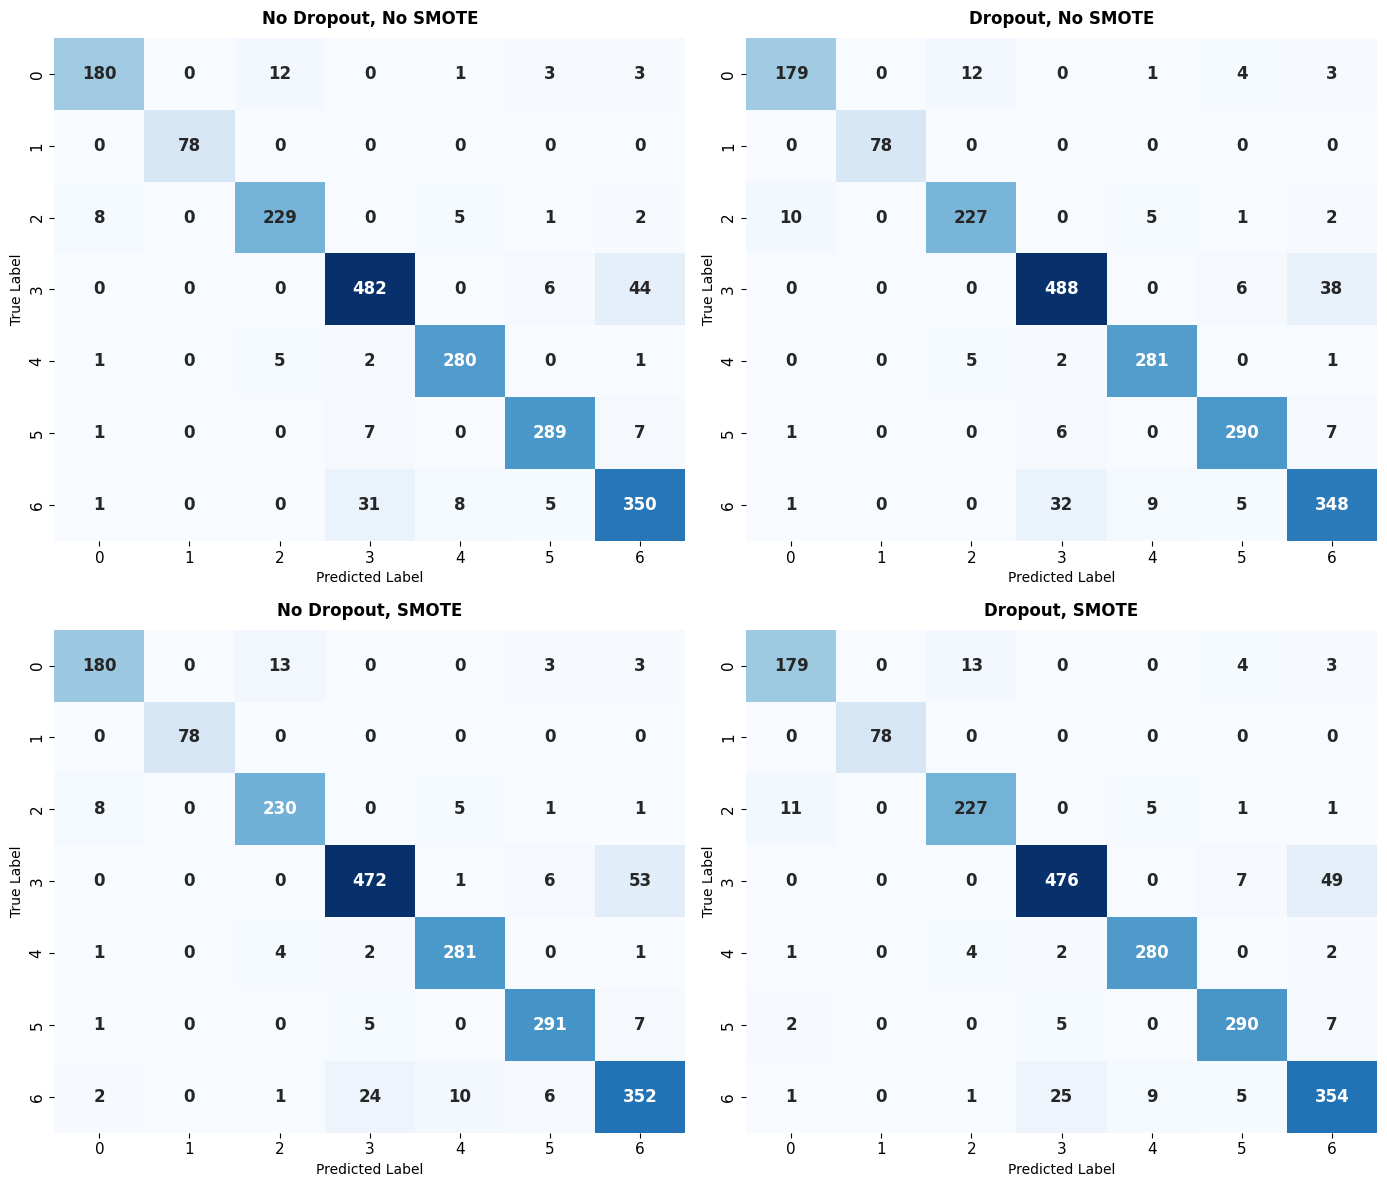

In [110]:
#Ma trận nhầm lẫn
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix

# ========================================================
# 1. Cấu hình danh sách kịch bản và nhãn lớp
# ========================================================
scenarios = [
    {"name": "No Dropout, No SMOTE", "model": model_no_dropout},
    {"name": "Dropout, No SMOTE", "model": model_dropout},
    {"name": "No Dropout, SMOTE", "model": model_no_dropout_smote},
    {"name": "Dropout, SMOTE", "model": model_dropout_smote},
]

# Lấy danh sách các nhãn duy nhất từ tập dữ liệu thực tế để gán trục tọa độ
class_labels = sorted(list(torch.unique(y_test_tensor).numpy()))

# Khởi tạo khung hình vẽ tổng thể gồm 4 biểu đồ con (2 hàng x 2 cột)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()  # Làm phẳng ma trận trục để duyệt vòng lặp dễ dàng

# ========================================================
# 2. Vòng lặp tính toán và vẽ từng ma trận nhầm lẫn
# ========================================================
for i, sc in enumerate(scenarios):
    model = sc["model"]
    model.eval()  # Đưa mô hình về chế độ đánh giá (tắt Dropout)

    with torch.no_grad():
        # Dự đoán logits và lấy chỉ số lớp có xác suất cao nhất
        outputs = model(X_test_tensor)
        _, preds = torch.max(outputs, 1)

    # Chuyển Tensor sang dạng mảng NumPy thô
    y_true = y_test_tensor.cpu().numpy()
    y_pred = preds.cpu().numpy()

    # Tính toán ma trận nhầm lẫn từ scikit-learn
    cm = confusion_matrix(y_true, y_pred)

    # Sử dụng Seaborn Heatmap để trực quan hóa dữ liệu ma trận
    # - annot=True: Hiển thị số lượng mẫu trực tiếp lên ô
    # - fmt='d': Hiển thị định dạng số nguyên thuần túy
    # - cmap='Blues': Sử dụng dải màu xanh dương (đậm dần theo số lượng)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        xticklabels=class_labels,
        yticklabels=class_labels,
        cbar=False,  # Ẩn thanh thang đo màu để hình gọn gàng hơn
        annot_kws={"size": 12, "weight": "bold"},
    )

    # Cấu hình tiêu đề và các nhãn trục cho từng đồ thị con
    axes[i].set_title(sc["name"], fontsize=12, fontweight="bold", pad=10)
    axes[i].set_xlabel("Predicted Label", fontsize=10)
    axes[i].set_ylabel("True Label", fontsize=10)

# Cân đối khoảng cách tổng thể để tránh hiện tượng chữ bị đè dính vào nhau
plt.tight_layout()
plt.show()

In [111]:
from sklearn.metrics import classification_report

# Đưa mô hình về chế độ đánh giá
model_no_dropout.eval()
model_no_dropout_smote.eval()

with torch.no_grad():
    # 1. Dự đoán của kịch bản KHÔNG có SMOTE
    outputs_no = model_no_dropout(X_test_tensor)
    _, preds_no = torch.max(outputs_no, 1)

    # 2. Dự đoán của kịch bản CÓ SMOTE
    outputs_smote = model_no_dropout_smote(X_test_tensor)
    _, preds_smote = torch.max(outputs_smote, 1)

y_true = y_test_tensor.cpu().numpy()

print("============= KỊCH BẢN: KHÔNG CÓ SMOTE =============")
print(classification_report(y_true, preds_no.cpu().numpy(), target_names=[f"Lớp {c}" for c in class_labels]))

print("\n============= KỊCH BẢN: CÓ SMOTE =============")
print(classification_report(y_true, preds_smote.cpu().numpy(), target_names=[f"Lớp {c}" for c in class_labels]))

============= KỊCH BẢN: KHÔNG CÓ SMOTE =============
              precision    recall  f1-score   support

       Lớp 0       0.94      0.90      0.92       199
       Lớp 1       1.00      1.00      1.00        78
       Lớp 2       0.93      0.93      0.93       245
       Lớp 3       0.92      0.91      0.91       532
       Lớp 4       0.95      0.97      0.96       289
       Lớp 5       0.95      0.95      0.95       304
       Lớp 6       0.86      0.89      0.87       395

    accuracy                           0.92      2042
   macro avg       0.94      0.94      0.94      2042
weighted avg       0.92      0.92      0.92      2042


============= KỊCH BẢN: CÓ SMOTE =============
              precision    recall  f1-score   support

       Lớp 0       0.94      0.90      0.92       199
       Lớp 1       1.00      1.00      1.00        78
       Lớp 2       0.93      0.94      0.93       245
       Lớp 3       0.94      0.89      0.91       532
       Lớp 4       0.95      0.